In [34]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=False)
#rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

In [9]:
fid = {'Omega_m': 0.31, 'h': 0.67, 'log10As': 3.044, 'mu0': 0.0, 'sigma0': 0.0}

muq1_shear = {'std': {'Omega_m': 0.006, 'h': 0.006, 'log10As': 0.05, 'mu0': 0.2},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.0},
}

mu_pcalin_shear = {'std': {'Omega_m': 0.01, 'h': 0.01, 'log10As': 0.08, 'mu0': 0.55},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.0},
}

mu_pcapseudo_shear = {'std': {'Omega_m': 0.011, 'h': 0.01, 'log10As': 0.05, 'mu0': 0.35},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.0},
}

muq1_3x2pt= {'std': {'Omega_m': 0.008, 'h': 0.008, 'log10As': 0.06, 'mu0': 0.1, 'sigma0':0.1},
        'mean': {'Omega_m': 0.3105, 'h': 0.675, 'log10As': 3.046, 'mu0': 0.01, 'sigma0':0.},
        'err_minus': {'Omega_m': 0.008, 'h': 0.008, 'log10As': 0.06, 'mu0': 0.1, 'sigma0':0.1},
        'err_plus':{'Omega_m': 0.008, 'h': 0.008, 'log10As': 0.06, 'mu0': 0.1, 'sigma0':0.1},
}


mu_pcapseudo_3x2pt = {'std': {'Omega_m': 0.012, 'h': 0.012, 'log10As': 0.09, 'mu0': 0.2, 'sigma0':0.2},
        'mean': {'Omega_m': 0.3105, 'h': 0.675, 'log10As': 3.046, 'mu0': 0.01, 'sigma0':0.},
}


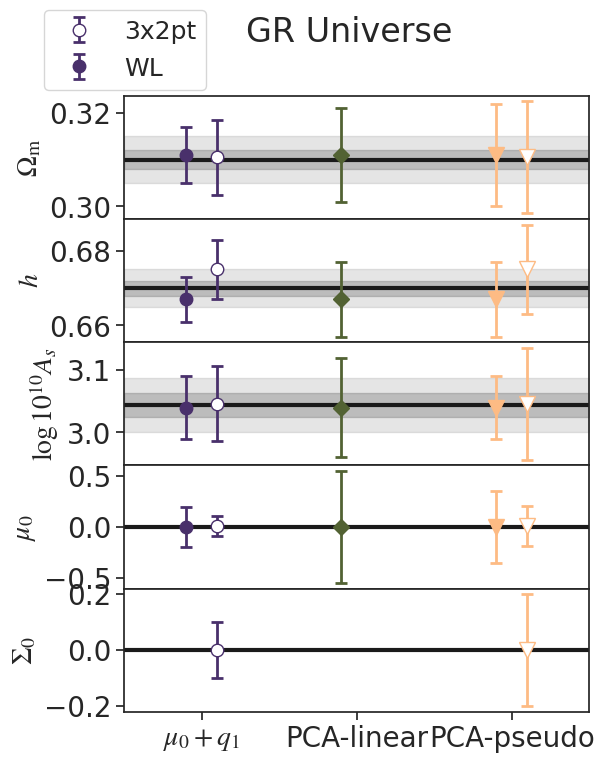

In [10]:
fig, ax = plt.subplots(5, 1, figsize=(6, 8), facecolor='w', sharex=True, gridspec_kw={'hspace': 0.0})
colors = ['#49306B', '#526233', '#fdbb84']
#colors = ['#7f0000', '#e34a33', '#fdbb84']
style_muq1 = dict(fmt='o', markersize=9, markeredgecolor=colors[0], markerfacecolor=colors[0],
                 ecolor=colors[0], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcalin = dict(fmt='D', markersize=8, markeredgecolor=colors[1], markerfacecolor=colors[1],
                    ecolor=colors[1], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcapseudo = dict(fmt='v', markersize=11, markeredgecolor=colors[2], markerfacecolor=colors[2],
                       ecolor=colors[2], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')

style_muq1_3x2pt = dict(fmt='o', markersize=9, markeredgecolor=colors[0], markerfacecolor='white',
                 ecolor=colors[0], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcalin_3x2pt = dict(fmt='D', markersize=8, markeredgecolor=colors[1], markerfacecolor='white',
                    ecolor=colors[1], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')
style_pcapseudo_3x2pt = dict(fmt='v', markersize=11, markeredgecolor=colors[2], markerfacecolor='white',
                       ecolor=colors[2], elinewidth=2.0, capsize=4, capthick=2.0, linestyle='None')

shift=0.1


for i in range(5):
    key = list(fid.keys())[i]
    ax[i].axhline(fid[key], color='k', linestyle='-')
    ax[i].errorbar([1.+shift], [muq1_3x2pt['mean'][key]], yerr=[[muq1_3x2pt['err_minus'][key]], [muq1_3x2pt['err_plus'][key]]], **style_muq1_3x2pt, label='3x2pt' if i==0 else '')
    #ax[i].errorbar([2.+shift], [mu_pcalin_3x2pt['mean'][key]], yerr=[mu_pcalin_3x2pt['std'][key]], **style_pcalin_3x2pt)
    ax[i].errorbar([3.+shift], [mu_pcapseudo_3x2pt['mean'][key]], yerr=[mu_pcapseudo_3x2pt['std'][key]], **style_pcapseudo_3x2pt)

for i in range(4):
    key = list(fid.keys())[i]
    eb1 = ax[i].errorbar([1-shift], [muq1_shear['mean'][key]], yerr=[muq1_shear['std'][key]], **style_muq1, label='WL' if i==0 else '')
    eb2 = ax[i].errorbar([2-shift], [mu_pcalin_shear['mean'][key]], yerr=[mu_pcalin_shear['std'][key]], **style_pcalin)
    eb3 = ax[i].errorbar([3-shift], [mu_pcapseudo_shear['mean'][key]], yerr=[mu_pcapseudo_shear['std'][key]], **style_pcapseudo)
    #for eb in (eb1, eb2, eb3):
    #    for barcol in eb[2]:
    #        barcol.set_linestyle('--')


ax[4].set_xticks([1, 2, 3])
ax[4].set_xticklabels(['$\mu_0+q_1$', 'PCA-linear', 'PCA-pseudo'])
ax[0].set_ylabel("$\Omega_{\\rm m}$")
ax[1].set_ylabel("$h$")
ax[2].set_ylabel("$\log{10^{10}A_s}$")
ax[4].set_ylabel("$\Sigma_0$")
ax[3].set_ylabel("$\mu_0$")
ax[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 1.8))
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.305, 0.315, color='tab:gray', alpha=0.2)
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.308, 0.312, color='tab:gray', alpha=0.4)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.665, 0.675, color='tab:gray', alpha=0.2)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.668, 0.672, color='tab:gray', alpha=0.4)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3., 3.088, color='tab:gray', alpha=0.2)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3.024, 3.064, color='tab:gray', alpha=0.4)
ax[0].set_xlim(0.5, 3.5)
fig.suptitle("GR Universe")
plt.show()

In [11]:
muq1_shear = {'std': {'Omega_m': 0.005, 'h': 0.01, 'log10As': 0.05, 'mu0': 0.08},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.1, 'mu0': 0.5},
}

mu_pcalin_shear = {'std': {'Omega_m': 0.012, 'h': 0.015, 'log10As': 0.08, 'mu0': 0.22},
        'mean': {'Omega_m': 0.317, 'h': 0.66, 'log10As': 3.12, 'mu0': 0.15},
}

mu_pcapseudo_shear = {'std': {'Omega_m': 0.018, 'h': 0.02, 'log10As': 0.05, 'mu0': 0.16},
        'mean': {'Omega_m': 0.311, 'h': 0.667, 'log10As': 3.1, 'mu0': 0.25},
}

muq1_3x2pt= {'std': {'Omega_m': 0.01, 'h': 0.02, 'log10As': 0.09, 'mu0': 0.2, 'sigma0':0.1},
        'mean': {'Omega_m': 0.31, 'h': 0.667, 'log10As': 3.05, 'mu0': 0.5, 'sigma0':0.},
}


mu_pcapseudo_3x2pt = {'std': {'Omega_m': 0.012, 'h': 0.02, 'log10As': 0.09, 'mu0': 0.2, 'sigma0':0.1},
        'mean': {'Omega_m': 0.31, 'h': 0.667, 'log10As': 3.05, 'mu0': 0.25, 'sigma0':0.},
}


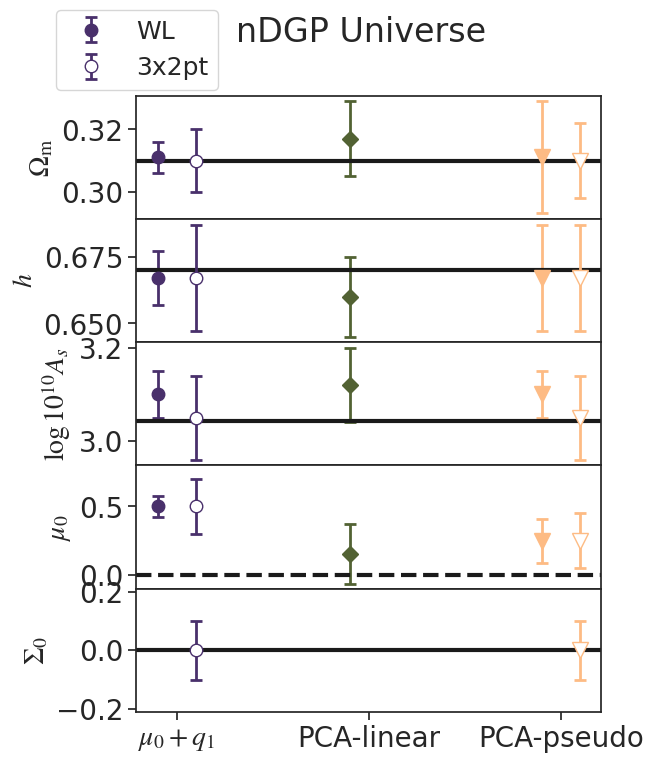

In [12]:
fig, ax = plt.subplots(5, 1, figsize=(6, 8), facecolor='w', sharex=True, gridspec_kw={'hspace': 0.0})
shift=0.1

for i in range(4):
    key = list(fid.keys())[i]
    eb1 = ax[i].errorbar([1-shift], [muq1_shear['mean'][key]], yerr=[muq1_shear['std'][key]], **style_muq1, label='WL' if i==0 else '')
    eb2 = ax[i].errorbar([2-shift], [mu_pcalin_shear['mean'][key]], yerr=[mu_pcalin_shear['std'][key]], **style_pcalin)
    eb3 = ax[i].errorbar([3-shift], [mu_pcapseudo_shear['mean'][key]], yerr=[mu_pcapseudo_shear['std'][key]], **style_pcapseudo)
    #for eb in (eb1, eb2, eb3):
    #    for barcol in eb[2]:
    #        barcol.set_linestyle('--')

for i in range(5):
    key = list(fid.keys())[i]
    ax[i].axhline(fid[key], color='k', linestyle='--' if i==3 else '-')
    ax[i].errorbar([1.+shift], [muq1_3x2pt['mean'][key]], yerr=[muq1_3x2pt['std'][key]], **style_muq1_3x2pt, label='3x2pt' if i==0 else '')
#    #ax[i].errorbar([2.+shift], [mu_pcalin_3x2pt['mean'][key]], yerr=[mu_pcalin_3x2pt['std'][key]], **style_pcalin_3x2pt)
    ax[i].errorbar([3.+shift], [mu_pcapseudo_3x2pt['mean'][key]], yerr=[mu_pcapseudo_3x2pt['std'][key]], **style_pcapseudo_3x2pt)

ax[4].set_xticks([1, 2, 3])
ax[4].set_xticklabels(['$\mu_0+q_1$', 'PCA-linear', 'PCA-pseudo'])
ax[0].set_ylabel("$\Omega_{\\rm m}$")
ax[1].set_ylabel("$h$")
ax[2].set_ylabel("$\log{10^{10}A_s}$")
ax[4].set_ylabel("$\Sigma_0$")
ax[3].set_ylabel("$\mu_0$")
ax[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 1.8))
ax[3].set_ylim(-0.1, 0.8)
ax[4].set_ylim(-0.21, 0.21)
fig.suptitle("nDGP Universe")
plt.show()

In [13]:
muq1_shear = {'std': {'Omega_m': 0.005, 'h': 0.01, 'log10As': 0.05, 'mu0': 0.25},
        'mean': {'Omega_m': 0.3, 'h': 0.72, 'log10As': 2.8, 'mu0': 0.5},
}

mu_pcalin_shear = {'std': {'Omega_m': 0.012, 'h': 0.015, 'log10As': 0.1, 'mu0': 0.5},
        'mean': {'Omega_m': 0.312, 'h': 0.67, 'log10As': 3., 'mu0': 0.},
}

mu_pcapseudo_shear = {'std': {'Omega_m': 0.015, 'h': 0.02, 'log10As': 0.05, 'mu0': 0.25},
        'mean': {'Omega_m': 0.3, 'h': 0.72, 'log10As': 2.9, 'mu0': 0.5},
}

fofr_pcapseudo_shear = {'std': {'Omega_m': 0.015, 'h': 0.02, 'log10As': 0.1, 'log10fofr': 0.5},
        'mean': {'Omega_m': 0.31, 'h': 0.67, 'log10As': 3.044, 'log10fofr': -5},
}

# muq1_3x2pt bi-modal

mu_pcapseudo_3x2pt = {'std': {'Omega_m': 0.012, 'h': 0.04, 'log10As': 0.1, 'mu0': 0.25, 'sigma0':0.1},
        'mean': {'Omega_m': 0.31, 'h': 0.667, 'log10As': 3.04, 'mu0': 0.5, 'sigma0':0.},
}

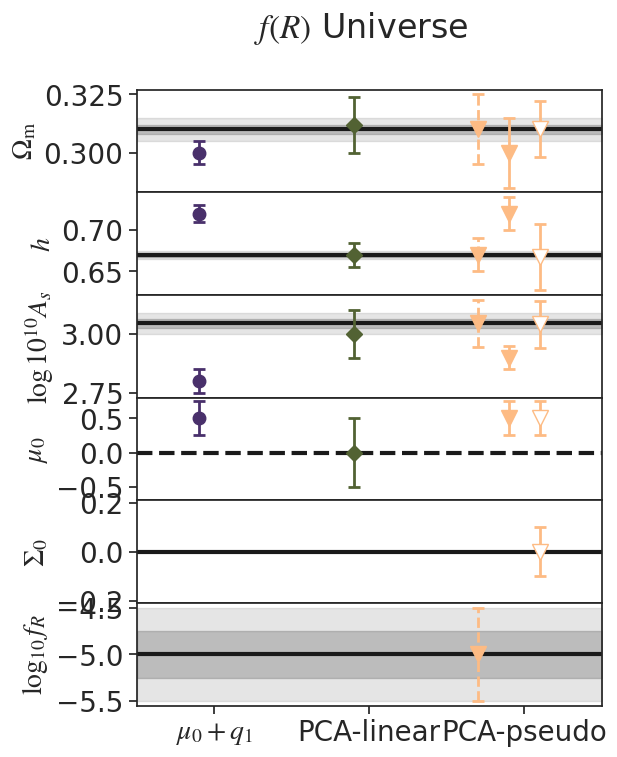

In [14]:
fig, ax = plt.subplots(6, 1, figsize=(6, 8), facecolor='w', sharex=True, gridspec_kw={'hspace': 0.0})
shift=0.1
for i in range(5):
    key = list(fid.keys())[i]
    ax[i].axhline(fid[key], color='k', linestyle='--' if i==3 else '-')
#    ax[i].errorbar([1.+shift], [muq1_3x2pt['mean'][key]], yerr=[muq1_3x2pt['std'][key]], **style_muq1_3x2pt, label='3x2pt' if i==0 else '')
#    #ax[i].errorbar([2.+shift], [mu_pcalin_3x2pt['mean'][key]], yerr=[mu_pcalin_3x2pt['std'][key]], **style_pcalin_3x2pt)
    ax[i].errorbar([3.+shift], [mu_pcapseudo_3x2pt['mean'][key]], yerr=[mu_pcapseudo_3x2pt['std'][key]], **style_pcapseudo_3x2pt)

for i in range(4):
    key = list(fid.keys())[i]
    eb1 = ax[i].errorbar([1-shift], [muq1_shear['mean'][key]], yerr=[muq1_shear['std'][key]], **style_muq1, label='WL' if i==0 else '')
    eb2 = ax[i].errorbar([2-shift], [mu_pcalin_shear['mean'][key]], yerr=[mu_pcalin_shear['std'][key]], **style_pcalin)
    eb3 = ax[i].errorbar([3-shift], [mu_pcapseudo_shear['mean'][key]], yerr=[mu_pcapseudo_shear['std'][key]], **style_pcapseudo)
    #for eb in (eb1, eb2, eb3):
    #    for barcol in eb[2]:
    #        barcol.set_linestyle('--')

for i in range(3):
    key = list(fid.keys())[i]
    eb3 = ax[i].errorbar([3-shift*3], [fofr_pcapseudo_shear['mean'][key]], yerr=[fofr_pcapseudo_shear['std'][key]], **style_pcapseudo)
    for barcol in eb3[2]:
            barcol.set_linestyle('--')
eb4 = ax[5].errorbar([3-shift*3], [fofr_pcapseudo_shear['mean']['log10fofr']], yerr=[fofr_pcapseudo_shear['std']['log10fofr']], **style_pcapseudo)
for barcol in eb4[2]:
            barcol.set_linestyle('--')
ax[4].set_xticks([1, 2, 3])
ax[4].set_xticklabels(['$\mu_0+q_1$', 'PCA-linear', 'PCA-pseudo'])
ax[0].set_ylabel("$\Omega_{\\rm m}$")
ax[1].set_ylabel("$h$")
ax[2].set_ylabel("$\log{10^{10}A_s}$")
ax[4].set_ylabel("$\Sigma_0$")
ax[3].set_ylabel("$\mu_0$")
ax[5].set_ylabel("$\log_{10}f_R$")
#ax[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 2.))
ax[3].set_ylim(-0.7, 0.8)
ax[4].set_ylim(-0.21, 0.21)
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.305, 0.315, color='tab:gray', alpha=0.2)
ax[0].fill_between(np.linspace(0.5, 3.5,10), 0.308, 0.312, color='tab:gray', alpha=0.4)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.665, 0.675, color='tab:gray', alpha=0.2)
ax[1].fill_between(np.linspace(0.5, 3.5,10), 0.668, 0.672, color='tab:gray', alpha=0.4)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3., 3.088, color='tab:gray', alpha=0.2)
ax[2].fill_between(np.linspace(0.5, 3.5,10), 3.024, 3.064, color='tab:gray', alpha=0.4)
ax[5].axhline(-5, color='k', linestyle='-')
ax[5].fill_between(np.linspace(0.5, 3.5,10), -5.5, -4.5, color='tab:gray', alpha=0.2)
ax[5].fill_between(np.linspace(0.5, 3.5,10), -5.25, -4.75, color='tab:gray', alpha=0.4)
ax[0].set_xlim(0.5, 3.5)
fig.suptitle("$f(R)$ Universe")
plt.show()

In [ ]:
# see current directory
print("Current directory:", os.getcwd())
# switch to the main directory
os.chdir('/home/c2042999/MGLensing/')

with open("pca_emcee_runs/params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

with open("ini_files/pca/params_data.yaml", "r") as file:
    fiducials = yaml.safe_load(file)

def read_last_header_line(file_path):
    last_header = None
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.startswith('#'):
                last_header = line.strip('#').strip()  
            else:
                break  

    if last_header:
        return last_header.split() 
    else:
        return []

def read_chains(file_paths):
    n_samples = len(file_paths)
    chains_info = {}
    for i in range(n_samples):
        file_path = file_paths[i]  
        chain = np.genfromtxt(file_path)
        chain_pars = read_last_header_line(file_path)
        chain_pars = chain_pars[:-2]
        chains_info[i] = {}
        chains_info[i]['chain'] = chain
        chains_info[i]['pars'] = chain_pars


    samples = []    
    for i in range(n_samples):
        samples.append(
            getdist.MCSamples(samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                                        names = [i for i in chains_info[i]['pars']],
                                        weights=np.exp(chains_info[i]['chain'][:, -2]),
                                        labels = [params_dic[p]
                                                    for p in chains_info[i]['pars']],
                                        settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
                                        ) 
        )
    return chains_info, samples

Current directory: /home/c2042999/MGLensing/pca_emcee_runs


In [28]:
os.chdir('/home/c2042999/MGLensing/pca_emcee_runs/')
file_paths = ['./chains/chain_GR_lsst_y1_pcacuts_ReACTemus.txt',
'./chains/chain_GR_lsst_y1_NLmodel.txt']
chains_info, samples = read_chains(file_paths)
ModelPars = chains_info[0]['pars']
ModelPars

Removed no burn in
Removed no burn in


['Omega_m', 'Ombh2', 'h', 'log10As', 'ns', 'mu0', 'a1_IA', 'eta1_IA']

In [29]:
samples[0].getLatex(limit=1)

(['\\Omega_{\\rm m}',
  '\\omega_{\\rm b}',
  'h',
  '\\log{10^{10}A_{\\rm s}}',
  'n_{\\rm s}',
  '\\mu_0',
  'A^{\\rm IA}_1',
  '\\eta^{\\rm IA}_1'],
 ['0.3195\\pm 0.0098',
  '0.02224\\pm 0.00038',
  '0.670\\pm 0.019',
  '3.036\\pm 0.072',
  '0.9626\\pm 0.0040',
  '0.01\\pm 0.39',
  '1.721\\pm 0.040',
  '-0.414\\pm 0.079'])

In [30]:
fofr_pcalin_shear = {'means': {}, 'err_minus': {}, 'err_plus': {}}
margeStats = samples[0].getMargeStats()
for par in ModelPars:
    fofr_pcalin_shear['means'][par] = margeStats.parWithName(par).mean
    fofr_pcalin_shear['err_minus'][par] = fofr_pcalin_shear['means'][par]-margeStats.parWithName(par).limits[0].lower
    fofr_pcalin_shear['err_plus'][par] = margeStats.parWithName(par).limits[1].upper-fofr_pcalin_shear['means'][par]

fofr_pcalin_shear

{'means': {'Omega_m': 0.31953866400735953,
  'Ombh2': 0.022241121024014668,
  'h': 0.6703188077096358,
  'log10As': 3.0361091382069314,
  'ns': 0.9625673225193854,
  'mu0': 0.008897158992191527,
  'a1_IA': 1.7213616709032598,
  'eta1_IA': -0.4138529136172597},
 'err_minus': {'Omega_m': 0.009933819277712419,
  'Ombh2': 0.00037806685817432656,
  'h': 0.019602711921849814,
  'log10As': 0.0740402783836509,
  'ns': 0.004007188852584553,
  'mu0': 0.3977911243899867,
  'a1_IA': 0.03852700728295266,
  'eta1_IA': 0.07880893916533421},
 'err_plus': {'Omega_m': 0.019682176760655257,
  'Ombh2': 0.0007722269825456013,
  'h': 0.036985487311687604,
  'log10As': 0.13896976121918092,
  'ns': 0.007739223176711274,
  'mu0': 0.7422160081318636,
  'a1_IA': 0.07955007402379177,
  'eta1_IA': 0.15382882556338834}}

In [ ]:
os.chdir('/home/c2042999/MGLensing/')



with open("tutorials/params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)




def read_last_header_line(file_path):
    last_header = None
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.startswith('#'):
                last_header = line.strip('#').strip()  
            else:
                break  

    if last_header:
        return last_header.split() 
    else:
        return []

file_paths = ['./pca_emcee_runs/chains/chain_GR_lsst_y1_pcacuts_ReACTemus.txt',
'./pca_emcee_runs/chains/chain_GR_lsst_y1_NLmodel.txt']


n_samples = len(file_paths)
chains_info = {}
for i in range(n_samples):
    file_path = file_paths[i]  
    chain = np.genfromtxt(file_path)
    chain_pars = read_last_header_line(file_path)

    chain_header = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.startswith('#'):
                chain_header.append(line.strip('#').strip())  
            else:
                break
    
    # save chain and parameter names
    chain_pars = chain_pars[:-2]
    chains_info[i] = {}
    chains_info[i]['chain'] = chain
    chains_info[i]['pars'] = chain_pars

    # save whether it is 3x2pt or shear-only from header info
    if any("Observable: shear-shear" in line for line in chain_header):
        chains_info[i]['observable'] = 'shear-shear'
    elif any("Observable: WL+XC+GC" in line for line in chain_header):
        chains_info[i]['observable'] = '3x2pt'
    else:
        raise ValueError("Observable type not found in header")
    
    # save ell_max WL,GC from header info (kmax not implemented)
    for line in chain_header:
        if "cut in l_max (WL)" in line:
            wl_lmax = [int(x) for x in line.split(":")[1].strip().strip("[]").split(",")]
            chains_info[i]['wl_lmax'] = max(wl_lmax)
        if "cut in l_max (GC, XC)" in line:
            gc_lmax = [int(x) for x in line.split(":")[1].strip().strip("[]").split(",")]
            chains_info[i]['gc_lmax'] = max(gc_lmax)

    # save Sky Fraction (fsky) and survey info
    for line in chain_header:
        if "Sky Fraction (fsky):" in line:
            chains_info[i]['fsky'] = float(line.split(":")[1].strip())
        if "for n(z)" in line:
            chains_info[i]['survey'] = line.split("z) ")[1].strip()


    # save Model name, by looking at two lines: # Data Model:
#             #   - Nonlinear Power Spectrum: HMcode (0)
    for j, line in enumerate(chain_header):
        if "Data Model:" in line:
            model_name = chain_header[j+1].split(":")[1].strip().split(" ")[0]
            chains_info[i]['model'] = model_name
    # save fiducial values from header info.
    # These are found in the lines after "Parameters:" and are in the format
    #  "param1=value1, 
    # param2=value2, ..."
    # ending with #         #
    for j, line in enumerate(chain_header):
        if "Parameters:" in line:
            # find number of parameters listed, by counting lines until we reach a line that contains "Theory Model:"
            n_params = 0
            for k in range(j+1, len(chain_header)):
                if "Theory Model:" in chain_header[k]:
                    break
                n_params += 1
            print(f"number of parameters: {n_params}")
            fid_line = chain_header[j+1:j+n_params+1]
            fid_values = {}
            for item in fid_line:
                if ":" in item:
                    _ , cleaned_item = item.split("- ")
                    param, value = cleaned_item.split(":")
                    fid_values[param.strip()] = float(value.strip())
            # keep fid values only for the parameters in the chain. If there is no fiducial for the given parameter, leave None.
            fid_values = {param: fid_values.get(param, None) for param in chains_info[i]['pars']}
            chains_info[i]['fiducials'] = fid_values
    print(f"Chain {i} parameters: {chains_info[i]['pars']}")
    print(f"Chain {i} observable type: {chains_info[i]['observable']}")
    print(f"Chain {i} wl_lmax: {chains_info[i]['wl_lmax']}")
    print(f"Chain {i} gc_lmax: {chains_info[i]['gc_lmax']}")
    print(f"Chain {i} fsky: {chains_info[i]['fsky']}")
    print(f"Chain {i} survey: {chains_info[i]['survey']}")
    print(f"Chain {i} fiducials: {chains_info[i]['fiducials']}")





number of parameters: 27
Chain 0 parameters: ['Omega_m', 'Ombh2', 'h', 'log10As', 'ns', 'mu0', 'a1_IA', 'eta1_IA']
Chain 0 observable type: shear-shear
Chain 0 wl_lmax: 3000
Chain 0 gc_lmax: 20
Chain 0 fsky: 0.43
Chain 0 survey: LSST-like
Chain 0 fiducials: {'Omega_m': 0.31966, 'Ombh2': 0.0222382981843968, 'h': 0.6688, 'log10As': 3.04070563, 'ns': 0.9626, 'mu0': None, 'a1_IA': 1.72, 'eta1_IA': -0.41}
number of parameters: 27
Chain 1 parameters: ['Omega_m', 'Ombh2', 'h', 'log10As', 'ns', 'mu0', 'q1', 'a1_IA', 'eta1_IA']
Chain 1 observable type: shear-shear
Chain 1 wl_lmax: 3000
Chain 1 gc_lmax: 20
Chain 1 fsky: 0.43
Chain 1 survey: LSST-like
Chain 1 fiducials: {'Omega_m': 0.31966, 'Ombh2': 0.0222382981843968, 'h': 0.6688, 'log10As': 3.04070563, 'ns': 0.9626, 'mu0': None, 'q1': None, 'a1_IA': 1.72, 'eta1_IA': -0.41}


Removed no burn in
Removed no burn in


Text(3.5, 0.05, 'shear-shear \n$\\ell^{\\rm WL}_{\\rm max}=3000$, $\\ell^{\\rm GC}_{\\rm max}=20$, $f_{\\rm sky}=0.43$ \n')

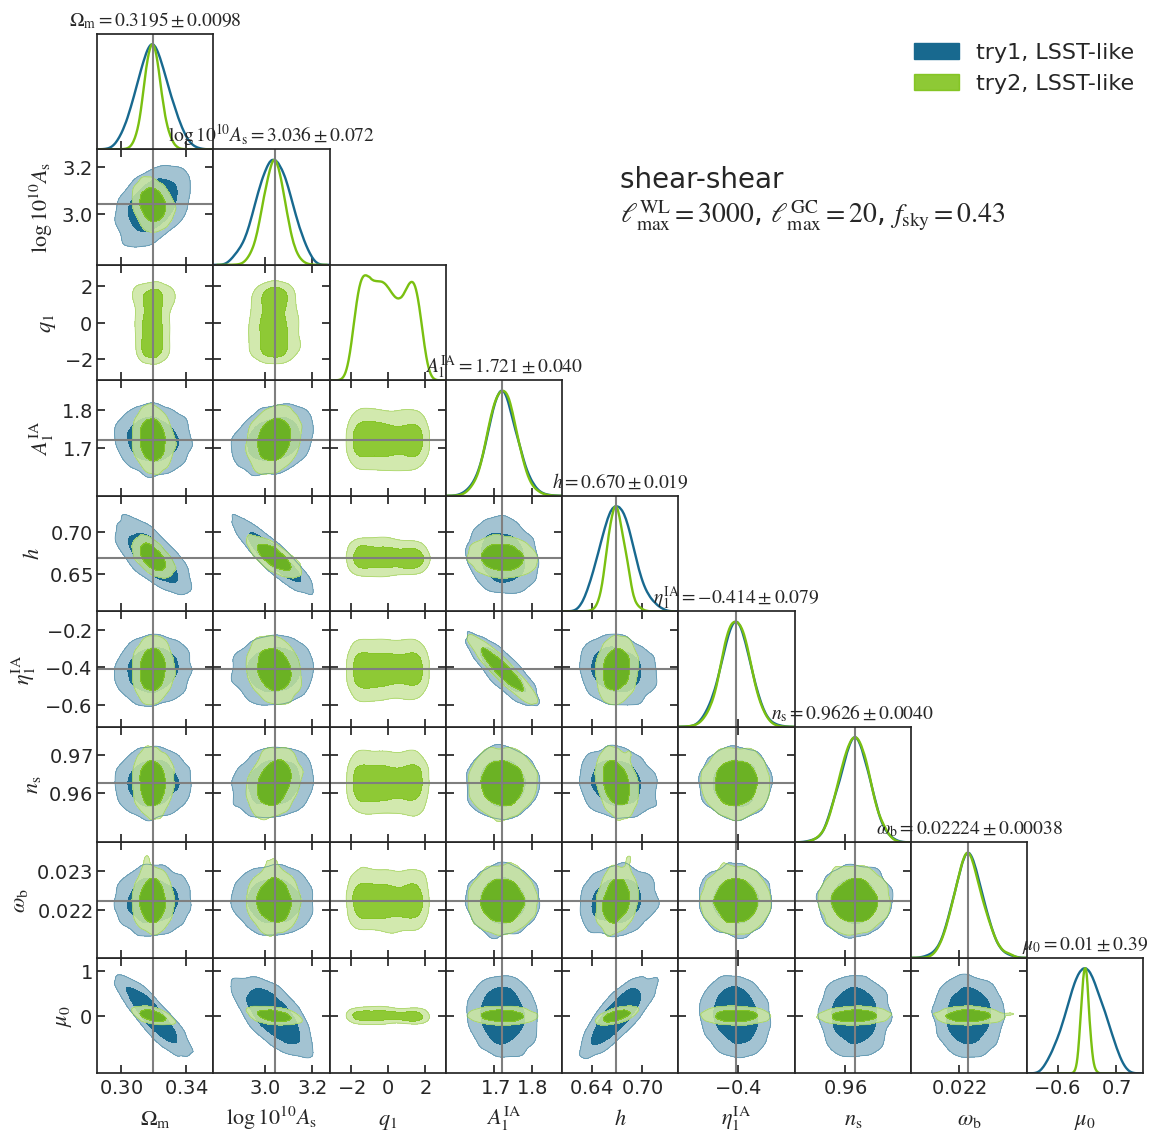

In [ ]:
samples = []    
for i in range(n_samples):
    samples.append(
        getdist.MCSamples(samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                                    names = [i for i in chains_info[i]['pars']],
                                    weights=np.exp(chains_info[i]['chain'][:, -2]),
                                    labels = [params_dic[p]
                                                for p in chains_info[i]['pars']],
                                    settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
                                    ) 
    )

# choose Model Pars so that they include all params from all chains
ModelPars = set()
for i in range(n_samples):
    ModelPars.update(chains_info[i]['pars'])
ModelPars = list(ModelPars)

colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4   
g.settings.figure_legend_frame = False

###
#legend_labels = []
# annotation_text = 'LSST Y1 data \n 3x2pt-analysis\n $\ell^{\\rm WL, GC}_{\\rm max}=2000, 100$'

### Find legend labels and annotation text. If observable type,  wl_lmax, gc_lmax, fsky, survey 
### are the same across chains, use them to create annotation text. Otherwise, use them in label for each chain
legend_labels = ["try1", "try2"]
annotation_text = ""
observable_types = set()
wl_lmax_values = set()
gc_lmax_values = set()
fsky_values = set()
survey_values = set()
for i in range(n_samples):
    observable_types.add(chains_info[i]['observable'])
    wl_lmax_values.add(chains_info[i]['wl_lmax'])
    gc_lmax_values.add(chains_info[i]['gc_lmax'])
    fsky_values.add(chains_info[i]['fsky'])
    survey_values.add(chains_info[i]['survey'])
if len(observable_types) == 1:
    annotation_text += f"{observable_types.pop()} \n"
else:
    if legend_labels == []:
        for i in range(n_samples):
            legend_labels.append(f"{chains_info[i]['observable']}")
    else:
        for i in range(n_samples):
            legend_labels[i] += f"{chains_info[i]['observable']}"
if len(wl_lmax_values) == 1:
    annotation_text += f"$\ell^{{\\rm WL}}_{{\\rm max}}={wl_lmax_values.pop()}$, "
else:
    if legend_labels == []:
        for i in range(n_samples):
            legend_labels.append(f"$\ell^{{\\rm WL}}_{{\\rm max}}={chains_info[i]['wl_lmax']}$")
    else:
        for i in range(n_samples):
            legend_labels[i] += f", $\ell^{{\\rm WL}}_{{\\rm max}}={chains_info[i]['wl_lmax']}$"
if len(gc_lmax_values) == 1:
    annotation_text += f"$\ell^{{\\rm GC}}_{{\\rm max}}={gc_lmax_values.pop()}$, "
else:
    if legend_labels == []:
        for i in range(n_samples):
            legend_labels.append(f"$\ell^{{\\rm GC}}_{{\\rm max}}={chains_info[i]['gc_lmax']}$")
    else:
        for i in range(n_samples):
            legend_labels[i] += f", $\ell^{{\\rm GC}}_{{\\rm max}}={chains_info[i]['gc_lmax']}$"
if len(fsky_values) == 1:
    annotation_text += f"$f_{{\\rm sky}}={fsky_values.pop()}$ \n"
else:
    if legend_labels == []:
        for i in range(n_samples):
            legend_labels.append(f"$f_{{\\rm sky}}={chains_info[i]['fsky']}$")
    else:
        for i in range(n_samples):
            legend_labels[i] += f", $f_{{\\rm sky}}={chains_info[i]['fsky']}$"
if len(survey_values) == 1:
    annotation_text += f"{survey_values.pop()}"
else:
    if legend_labels == []:
        for i in range(n_samples):        
            legend_labels.append(f"{chains_info[i]['survey']}")
    else:
        for i in range(n_samples):
            legend_labels[i] += f", {chains_info[i]['survey']}"

###

g.triangle_plot(samples,
    ModelPars,
    legend_labels = legend_labels,
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':False, 'color': colors[3], 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '--'}])

# find fiducials for each of the ModelPars. If a parameter is not found in the fiducials of either chain, set it to None.
fiducials = {}
for par in ModelPars:
    # assign fiducial value from all chains if it exists.
    for chain_i in chains_info:
        if par in chains_info[chain_i]['fiducials'] and chains_info[chain_i]['fiducials'][par] is not None:
            # check if fiducial value is the same across chains. If not, print a warning and set it to None.
            if par in fiducials and fiducials[par] != chains_info[chain_i]['fiducials'][par]:
                print(f"Warning: Fiducial value for parameter {par} is different across chains. Setting it to None.")
                fiducials[par] = None
                break
            fiducials[par] = chains_info[chain_i]['fiducials'][par]
    # if par is not found in any chain's fiducials, set it to None
    if par not in fiducials:
        fiducials[par] = None
    


if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]],lw=1.5,color='tab:gray')
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]],lw=1.5,color='tab:gray')


num = 1
ax = g.subplots[num, num]
ax.annotate(annotation_text, (3.5, 0.05), xycoords='axes fraction', clip_on=False, fontsize=20)  